In [64]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel("btcmaindata.xlsx")
df
#df.info()
#df.describe()

,Date,Close
0,2019-01-01,3500.00
1,2019-01-02,3559.15
2,2019-01-03,3551.51
3,2019-01-04,3627.62
4,2019-01-05,3800.62
...,...,...
1821,2023-12-27,1551748.20
1822,2023-12-28,1558429.34
1823,2023-12-29,1551033.53
1824,2023-12-30,1523890.32


In [65]:
# Stage 2 → you CLEAN this file (fix Date, drop nulls, sort)

df["Date"] = pd.to_datetime(df["Date"])

df = df.dropna(subset = ["Close"])

print("duplicates:",df.duplicated().sum())    # checked if there is any duplicates

df.sort_values("Date").reset_index(drop=True)


duplicates: 0


,Date,Close
0,2019-01-01,3500.00
1,2019-01-02,3559.15
2,2019-01-03,3551.51
3,2019-01-04,3627.62
4,2019-01-05,3800.62
...,...,...
1821,2023-12-27,1551748.20
1822,2023-12-28,1558429.34
1823,2023-12-29,1551033.53
1824,2023-12-30,1523890.32


In [66]:
#Stage 3 → you ADD new columns to this file (MA_200, Phase)

# 200-day moving average
df["MA_200"] = df["Close"].rolling(window=200).mean()

# Step 2 — drop rows where MA_200 is NaN (first 199 rows)
df = df.dropna(subset=["MA_200"])

# Step 3 — tag each day as Bull or Bear
df["Phase"] = "Bear"
df.loc[df["Close"] > df["MA_200"], "Phase"] = "Bull"


# Step 4 — extract Year
df["Year"] = df["Date"].dt.year
df




,Date,Close,MA_200,Phase,Year
199,2019-07-19,4410.22,3.587271e+03,Bull,2019
200,2019-07-20,4267.82,3.591110e+03,Bull,2019
201,2019-07-21,4322.16,3.594925e+03,Bull,2019
202,2019-07-22,4403.52,3.599185e+03,Bull,2019
203,2019-07-23,4555.40,3.603824e+03,Bull,2019
...,...,...,...,...,...
1821,2023-12-27,1551748.20,1.496965e+06,Bull,2023
1822,2023-12-28,1558429.34,1.501129e+06,Bull,2023
1823,2023-12-29,1551033.53,1.505148e+06,Bull,2023
1824,2023-12-30,1523890.32,1.509099e+06,Bull,2023


In [67]:
#Stage 4 → you ANALYSE this file (groupby Phase, groupby Year)

# Finding 1 — Bull vs Bear summary
phase_summary = df.groupby("Phase")["Close"].agg( avg_price = "mean",max_price ="max",total = "count").reset_index()
print("─── Finding 1: Bull vs Bear Summary ───")
df

# Finding 2 — Yearly average price
year_avg = df.groupby("Year")["Close"].agg(year_average="mean").reset_index()
print("\n─── Finding 2: Yearly Average Price ───")

# Finding 3 —  overall 5 year summary
total_days    = len(df)
bull_days     = len(df[df["Phase"] == "Bull"])
bear_days     = len(df[df["Phase"] == "Bear"])
bull_pct      = round((bull_days / total_days) * 100, 1)
bear_pct      = round((bear_days / total_days) * 100, 1)
all_time_high = df["Close"].max()
all_time_low  = df["Close"].min()
print(f"\n─── Overall 5 Year Summary ───")
print(f"Total Days Analysed : {total_days}")
print(f"Bull Days           : {bull_days} ({bull_pct}%)")
print(f"Bear Days           : {bear_days} ({bear_pct}%)")



─── Finding 1: Bull vs Bear Summary ───

─── Finding 2: Yearly Average Price ───

─── Overall 5 Year Summary ───
Total Days Analysed : 1627
Bull Days           : 1593 (97.9%)
Bear Days           : 34 (2.1%)


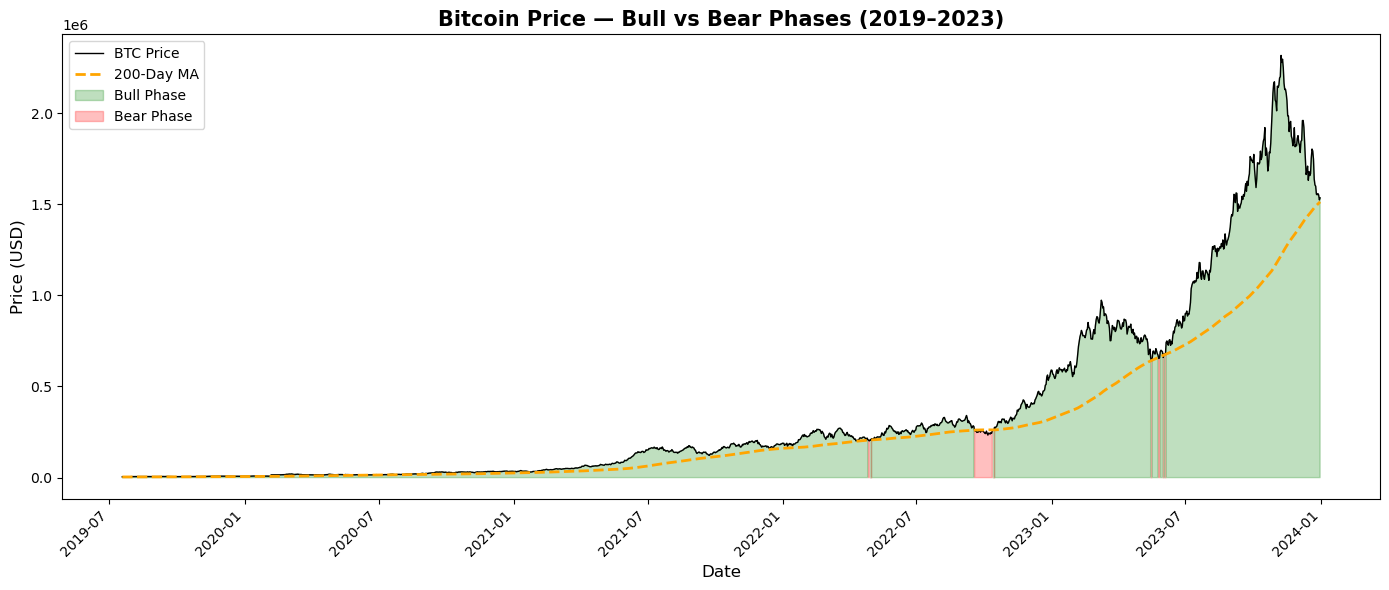

In [69]:
#Stage 5 → you VISUALIZE this file (all 3 charts use df)

fig, ax = plt.subplots(figsize=(14, 6))

# BTC price line
ax.plot(df["Date"], df["Close"],
        color="black",
        linewidth=1,
        label="BTC Price")

# 200-day moving average line
ax.plot(df["Date"], df["MA_200"],
        color="orange",
        linewidth=2,
        linestyle="--",
        label="200-Day MA")

# green shading = Bull phase
ax.fill_between(df["Date"], df["Close"],
                where=(df["Phase"] == "Bull"),
                alpha=0.25,
                color="green",
                label="Bull Phase")

# red shading = Bear phase
ax.fill_between(df["Date"], df["Close"],
                where=(df["Phase"] == "Bear"),
                alpha=0.25,
                color="red",
                label="Bear Phase")

ax.set_title("Bitcoin Price — Bull vs Bear Phases (2019–2023)",
             fontsize=15, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Price (USD)", fontsize=12)
ax.legend(fontsize=10)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("btc_chart.png", dpi=150)
plt.show()

